In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib

plt.rcParams['figure.max_open_warning'] = 0

plt.rcParams['text.usetex']        = True

#plt.rcParams['mathtext.fontset']  = 'stix'
#plt.rcParams['font.family']       = 'STIXGeneral'

plt.rcParams['font.size']         = 14
plt.rcParams['axes.linewidth']    = 1
plt.rcParams['axes.labelsize']    = plt.rcParams['font.size']
plt.rcParams['axes.titlesize']    = 1.5*plt.rcParams['font.size']
plt.rcParams['legend.fontsize']   = plt.rcParams['font.size']
plt.rcParams['xtick.labelsize']   = plt.rcParams['font.size']
plt.rcParams['ytick.labelsize']   = plt.rcParams['font.size']
plt.rcParams['xtick.major.size']  = 3
plt.rcParams['xtick.minor.size']  = 3
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['xtick.minor.width'] = 1
plt.rcParams['ytick.major.size']  = 3
plt.rcParams['ytick.minor.size']  = 3
plt.rcParams['ytick.major.width'] = 1
plt.rcParams['ytick.minor.width'] = 1

plt.rcParams['legend.frameon']             = False
plt.rcParams['legend.loc']                 = 'center left'
plt.rcParams['contour.negative_linestyle'] = 'solid'

import pyRing.waveform as wf
from pyRing.utils import *

/home/nishkal/anaconda3/envs/non_circular_ringdown/lib/python3.12/site-packages/lalsimulation/lalsimulation.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal
/home/nishkal/anaconda3/envs/non_circular_ringdown/lib/python3.12/site-packages/pyRingGW-2.7.0-py3.12-linux-x86_64.egg/pyRing/utils.py:66: UserWarning: * The `surfinBH` package is not automatically installed due to possible conflicts. If you wish to use its functionalities, it needs to be installed separa

In [2]:
srate   = 4096.0
T       = 2*80
times   = np.linspace(0, T/2., int(srate*T))

q = 1
M_tot = 1
nu = (q/(1.+q))**2

TEOBPM_params = {'t0'          : 0.0              ,
                'm1'          : (q/(1.+q))*M_tot ,
                'm2'          : (1./(1.+q))*M_tot,
                'chi1'        : 0.0              ,
                'chi2'        : 0.0              ,
                'distance'    : 50.0             ,
                'inclination' : 0.0              ,
                'phi'         : 0.0              }

modes = [(2,2)]
merger_phases = {mode : 0.0 for mode in modes}

fit_type = 'nu_bmrg'
fit_order = 1

NR_fit_coeffs = {
    'Mf'         : 0.9516104403,
    'af'         : 0.6863736768,
    (2, 2): {
        'A_peak_over_nu'        : 0.3932379086373926,
        'omg_peak'              : 0.3639127188544364,
        'A_nr_error'            : 0.001,
        'A_peakdotdot_over_nu'  : -0.0010276862556164,
        'ecc'                   : 0.0,
        'bmrg'                  : 3.093452852388823,
        'Emrg'                  : 0.8812299836092321,
        'Jmrg'                  : 2.810779766378831,
        'fit_type'              : fit_type,
        'fit_order'             : fit_order,

    }
}

In [3]:
fit_data = pd.read_csv('../src/data/fits/nc_fits_rit_non-spinning/order_fits_{}_{}.csv'.format(fit_type, fit_order))
fit_metadata = fit_data.iloc[0].to_dict()
fit_coeffs = {key: val for key, val in fit_metadata.items() if key.startswith(('c_2_', 'c_3_', 'c_4_'))}
NR_fit_coeffs[(2, 2)].update(fit_coeffs)

cmap = plt.cm.plasma_r
# param, key, label = np.linspace(0.0, 0.8, 20), 'ecc', '$e_0$'
# norm = plt.Normalize(vmin=0.0, vmax=0.8)
param, key, label = np.linspace(1.8, 3.5, 20), 'bmrg', '$\\hat{b}_{\\rm mrg}$'
norm = plt.Normalize(vmin=1.8, vmax=3.5)
# param, key, label = np.linspace(0.86, 0.98, 20), 'Emrg', '$\\hat{E}_{\\rm eff}^{\\rm mrg}$'
# norm = plt.Normalize(vmin=0.86, vmax=0.98)
# param, key, label = np.linspace(1.7, 3.2, 20), 'Jmrg', '$j_{\\rm mrg}$'
# norm = plt.Normalize(vmin=1.7, vmax=3.2)

import qnm
omega, _, _ = qnm.modes_cache(s=-2, l=2, m=2, n=0)(a=np.abs(NR_fit_coeffs['af']))
f_rd_fundamental = (np.real(omega) / NR_fit_coeffs['Mf']) / (2.0 * np.pi)
tau_rd_fundamental = -1.0 / (np.imag(omega)) * NR_fit_coeffs['Mf']

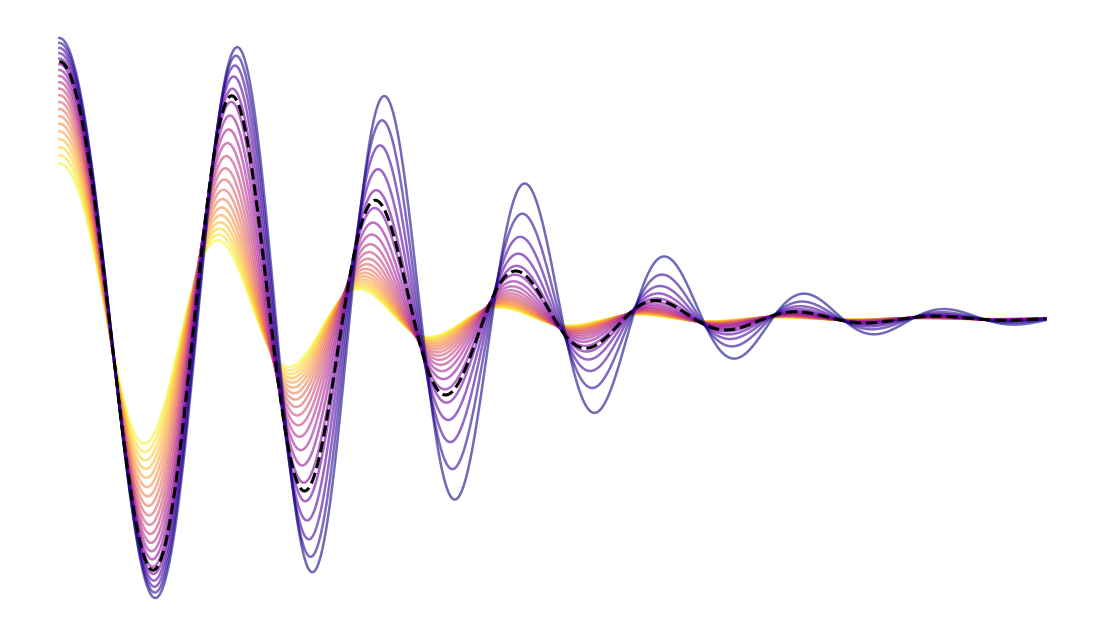

In [7]:
label_data = 'h_{22}'

COL = {
    'model': '#cc0033',
    't_start': 'mediumseagreen',
    't_peak': 'royalblue',
    'f_overt': 'darkorange',
    'f_ring': 'forestgreen',
}

alpha_wf = 0.6
alpha_std = 0.6
alpha_med = 0.8

LS = {
    't': '--',
    'f': '--',
}

LW = {
    'small': 0.5,
    'medium': 1.2,
    'std': 1.8,
    'large': 2.2,
}

FONTS = {
    'legend': 18,
    'labels': 22,
}

plot_wf = dict(lw=LW['std'], alpha=alpha_wf, ls='-')
plot_std = dict(lw=LW['std'], alpha=alpha_std, ls='-')
vline_std = dict(lw=LW['std'], alpha=alpha_std, ls=LS['t'])
vline_peak = dict(lw=LW['std'], alpha=alpha_std, ls=LS['t'])
ax2_semilogy_kwargs = dict(lw=LW['std'], alpha=alpha_std, ls='-')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig, axes = plt.subplots(1, 1, figsize=(14, 8))

for x in param:
    NR_fit_coeffs[(2,2)][key] = x
    NR_fit_coeffs[(2,2)]['A_peak_over_nu'] = 0.33785187637954517*(1-9.55316588158424*nu+25.93390782245145*x-8.788312537122415*nu**2+22.309037834286425*x**2)/(1-0.528855353085208*nu+0.0696058868968051*x-0.5778588139083378*nu**2+0.0835886717156238*x**2)

    TEOBPM_model = wf.TEOBPM(TEOBPM_params['t0']         ,
                            TEOBPM_params['m1']         ,
                            TEOBPM_params['m2']         ,
                            TEOBPM_params['chi1']       ,
                            TEOBPM_params['chi2']       ,
                            merger_phases               ,
                            TEOBPM_params['distance']   ,
                            TEOBPM_params['inclination'],
                            TEOBPM_params['phi']        ,
                            modes                       ,
                            {}                          ,
                            geom = 1                    ,
                            ecc_par = 1                 ,
                            NR_fit_coeffs = NR_fit_coeffs
                            )

    _, _, _, hp_TEOB, hc_TEOB = TEOBPM_model.waveform(times)

    amp = np.sqrt(hp_TEOB**2 + hc_TEOB**2)

    phase = np.unwrap(-np.angle(hp_TEOB - 1j*hc_TEOB))
    ang_freq = np.gradient(phase, times)/(2*np.pi)

    t_NR = times
    t_peak = 0
    tM_start = 0

    NR_r = hp_TEOB/100
    NR_i = hc_TEOB/100
    NR_amp = amp/100
    NR_f = ang_freq

    color = cmap(norm(x))

    axes.plot(t_NR - t_peak, NR_r, c=color, **plot_wf)

qc_val = 3.0935
NR_fit_coeffs[(2,2)][key] = qc_val
NR_fit_coeffs[(2,2)]['A_peak_over_nu'] = 0.33785187637954517*(1-9.55316588158424*nu+25.93390782245145*qc_val-8.788312537122415*nu**2+22.309037834286425*qc_val**2)/(1-0.528855353085208*nu+0.0696058868968051*qc_val-0.5778588139083378*nu**2+0.0835886717156238*qc_val**2)

TEOBPM_model_qc = wf.TEOBPM(
    TEOBPM_params['t0'], TEOBPM_params['m1'], TEOBPM_params['m2'],
    TEOBPM_params['chi1'], TEOBPM_params['chi2'], merger_phases,
    TEOBPM_params['distance'], TEOBPM_params['inclination'], TEOBPM_params['phi'],
    modes, {}, geom=1, ecc_par=1, NR_fit_coeffs=NR_fit_coeffs
)

_, _, _, hp_TEOB_qc, hc_TEOB_qc = TEOBPM_model_qc.waveform(times)
amp_qc = np.sqrt(hp_TEOB_qc**2 + hc_TEOB_qc**2)
phase_qc = np.unwrap(-np.angle(hp_TEOB_qc - 1j*hc_TEOB_qc))
ang_freq_qc = np.gradient(phase_qc, times) / (2*np.pi)

qc_label = r'$\rm{QC}$'
qc_kwargs = dict(c='k', ls='--', lw=LW['large'], zorder=10)

axes.plot(times, hp_TEOB_qc/100, **qc_kwargs)

plt.axis('off')
fig.subplots_adjust(right=0.9, wspace=0.3)

plt.savefig('nc_waveforms.pdf', bbox_inches='tight')
plt.show()

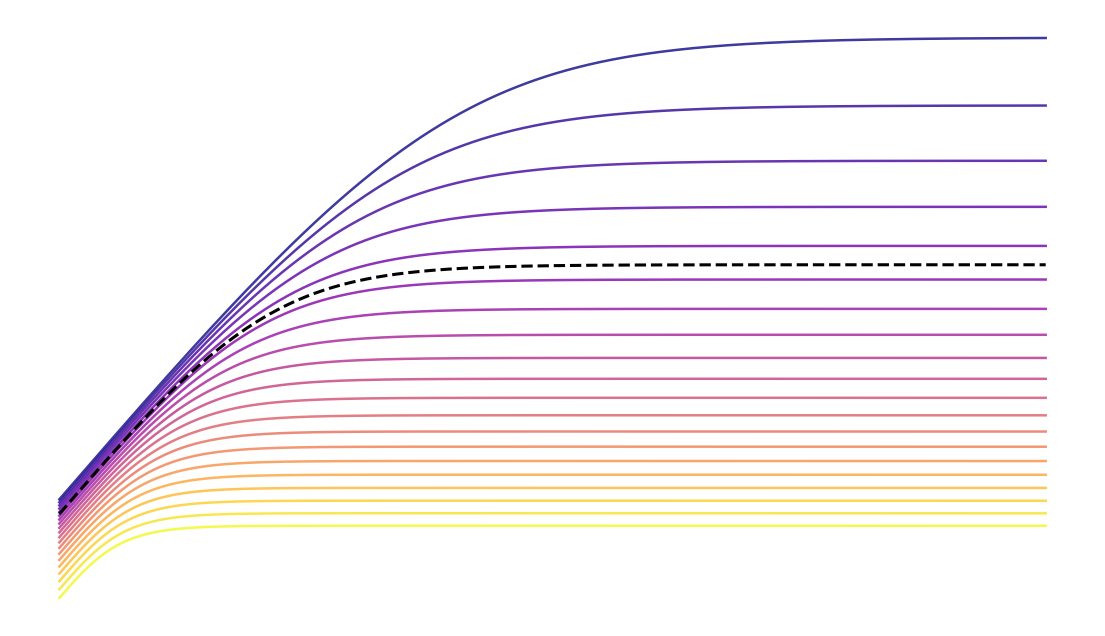

In [ ]:
# label_data = 'h_{22}'

# COL = {
#     'model': '#cc0033',
#     't_start': 'mediumseagreen',
#     't_peak': 'royalblue',
#     'f_overt': 'darkorange',
#     'f_ring': 'forestgreen',
# }

# alpha_wf = 0.6
# alpha_std = 0.8
# alpha_med = 0.8

# LS = {
#     't': '--',
#     'f': '--',
# }

# LW = {
#     'small': 0.5,
#     'medium': 1.2,
#     'std': 1.8,
#     'large': 2.2,
# }

# FONTS = {
#     'legend': 18,
#     'labels': 22,
# }

# plot_wf = dict(lw=LW['std'], alpha=alpha_wf, ls='-')
# plot_std = dict(lw=LW['std'], alpha=alpha_std, ls='-')
# vline_std = dict(lw=LW['std'], alpha=alpha_std, ls=LS['t'])
# vline_peak = dict(lw=LW['std'], alpha=alpha_std, ls=LS['t'])
# ax2_semilogy_kwargs = dict(lw=LW['std'], alpha=alpha_std, ls='-')

# sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])

# fig, axes = plt.subplots(1, 1, figsize=(14, 8))

# for x in param:
#     NR_fit_coeffs[(2,2)][key] = x
#     NR_fit_coeffs[(2,2)]['A_peak_over_nu'] = 0.33785187637954517*(1-9.55316588158424*nu+25.93390782245145*x-8.788312537122415*nu**2+22.309037834286425*x**2)/(1-0.528855353085208*nu+0.0696058868968051*x-0.5778588139083378*nu**2+0.0835886717156238*x**2)

#     TEOBPM_model = wf.TEOBPM(TEOBPM_params['t0']         ,
#                             TEOBPM_params['m1']         ,
#                             TEOBPM_params['m2']         ,
#                             TEOBPM_params['chi1']       ,
#                             TEOBPM_params['chi2']       ,
#                             merger_phases               ,
#                             TEOBPM_params['distance']   ,
#                             TEOBPM_params['inclination'],
#                             TEOBPM_params['phi']        ,
#                             modes                       ,
#                             {}                          ,
#                             geom = 1                    ,
#                             ecc_par = 1                 ,
#                             NR_fit_coeffs = NR_fit_coeffs
#                             )

#     _, _, _, hp_TEOB, hc_TEOB = TEOBPM_model.waveform(times)

#     amp = np.sqrt(hp_TEOB**2 + hc_TEOB**2)

#     phase = np.unwrap(-np.angle(hp_TEOB - 1j*hc_TEOB))
#     ang_freq = np.gradient(phase, times)/(2*np.pi)

#     t_NR = times
#     t_peak = 0
#     tM_start = 0

#     NR_r = hp_TEOB/100
#     NR_i = hc_TEOB/100
#     NR_amp = amp/100
#     NR_f = ang_freq

#     color = cmap(norm(x))

#     axes.semilogy(t_NR - t_peak,
#              NR_amp * np.exp((t_NR - t_peak) / tau_rd_fundamental),
#              c=color, **ax2_semilogy_kwargs)

# qc_val = 3.0935
# NR_fit_coeffs[(2,2)][key] = qc_val
# NR_fit_coeffs[(2,2)]['A_peak_over_nu'] = 0.33785187637954517*(1-9.55316588158424*nu+25.93390782245145*qc_val-8.788312537122415*nu**2+22.309037834286425*qc_val**2)/(1-0.528855353085208*nu+0.0696058868968051*qc_val-0.5778588139083378*nu**2+0.0835886717156238*qc_val**2)

# TEOBPM_model_qc = wf.TEOBPM(
#     TEOBPM_params['t0'], TEOBPM_params['m1'], TEOBPM_params['m2'],
#     TEOBPM_params['chi1'], TEOBPM_params['chi2'], merger_phases,
#     TEOBPM_params['distance'], TEOBPM_params['inclination'], TEOBPM_params['phi'],
#     modes, {}, geom=1, ecc_par=1, NR_fit_coeffs=NR_fit_coeffs
# )

# _, _, _, hp_TEOB_qc, hc_TEOB_qc = TEOBPM_model_qc.waveform(times)
# amp_qc = np.sqrt(hp_TEOB_qc**2 + hc_TEOB_qc**2)
# phase_qc = np.unwrap(-np.angle(hp_TEOB_qc - 1j*hc_TEOB_qc))
# ang_freq_qc = np.gradient(phase_qc, times) / (2*np.pi)

# qc_label = r'$\rm{QC}$'
# qc_kwargs = dict(c='k', ls='--', lw=LW['large'], zorder=10)

# axes.semilogy(times, (amp_qc/100) * np.exp(times / tau_rd_fundamental), **qc_kwargs)

# plt.axis('off')
# fig.subplots_adjust(right=0.9, wspace=0.3)

# plt.savefig('nc_amps.pdf', bbox_inches='tight')
# plt.show()